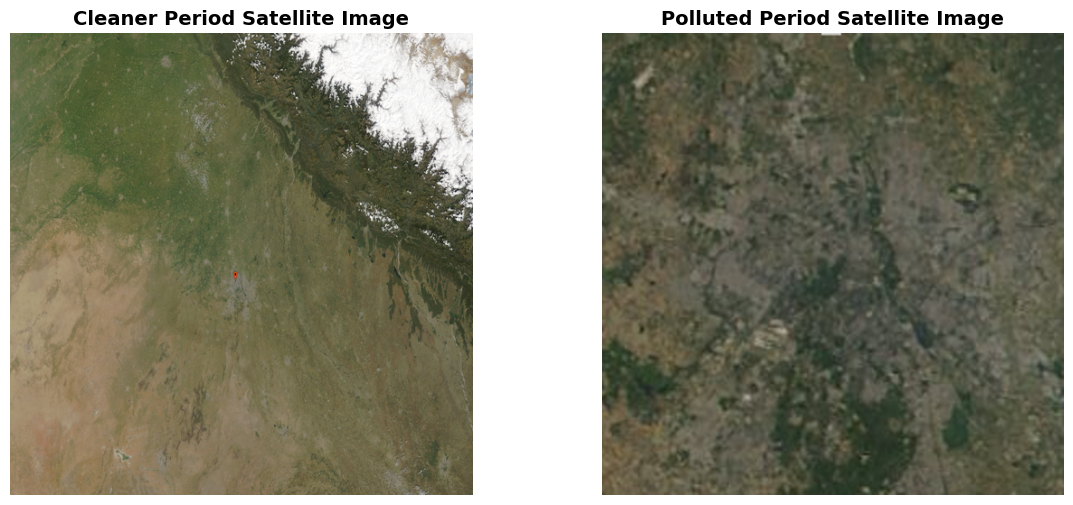

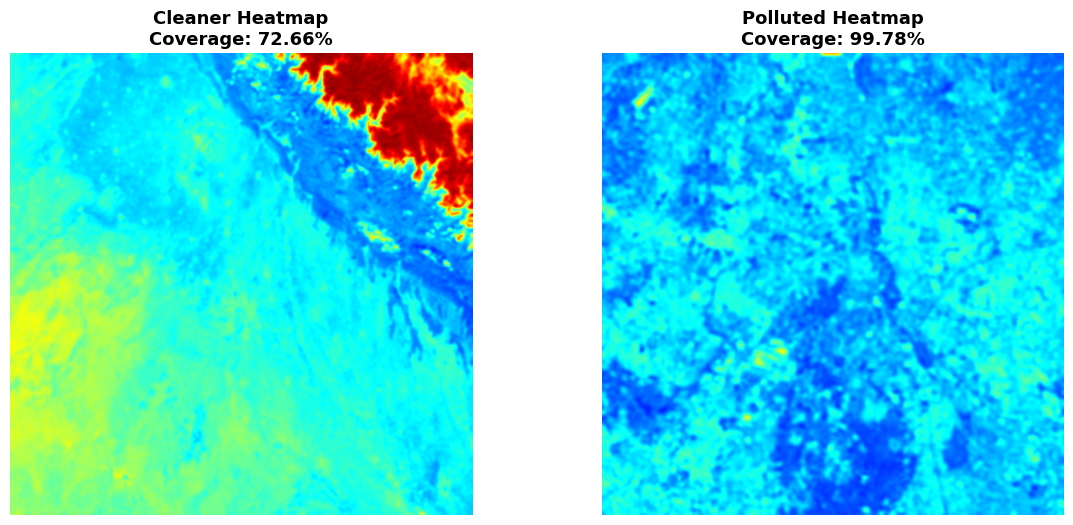

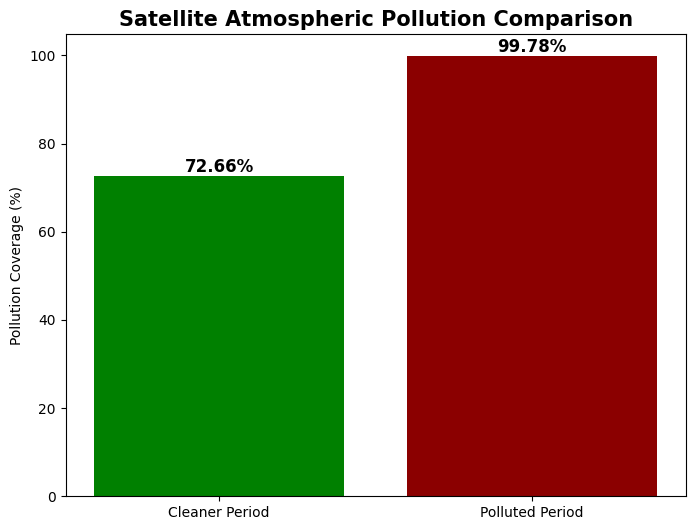

SATELLITE INTELLIGENCE INSIGHTS
Cleaner atmospheric condition: High Pollution
Polluted atmospheric condition: High Pollution
Coverage difference: 27.12%

INTERPRETATION:
Polluted satellite image shows reduced visibility due to haze/smog.
Higher atmospheric pollution density detected.
Satellite imagery visually confirms degraded air quality.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# IMAGE PATHS
# ==========================================
clean_image_path = r"C:\Users\hi\Desktop\AQI MAJOR PROJECT\satellite images\2020\april\2020-04-01.png"
polluted_image_path = r"C:\Users\hi\Desktop\AQI MAJOR PROJECT\satellite images\2024\october\2024-10-11.png"

# ==========================================
# IMAGE PROCESSING
# ==========================================
def process_satellite_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((512, 512))
    img_np = np.array(img)

    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    _, mask = cv2.threshold(
        blur,
        120,
        255,
        cv2.THRESH_BINARY_INV
    )

    heatmap = cv2.applyColorMap(
        blur,
        cv2.COLORMAP_JET
    )

    polluted_pixels = np.sum(mask == 255)
    total_pixels = mask.size
    coverage = (polluted_pixels / total_pixels) * 100

    if coverage < 20:
        level = "Low Pollution"
    elif coverage < 40:
        level = "Moderate Pollution"
    else:
        level = "High Pollution"

    return {
        "original": img_np,
        "heatmap": cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB),
        "coverage": coverage,
        "level": level
    }

# ==========================================
# PROCESS IMAGES
# ==========================================
clean = process_satellite_image(clean_image_path)
polluted = process_satellite_image(polluted_image_path)

# ==========================================
# ORIGINAL IMAGE COMPARISON
# ==========================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(clean["original"])
plt.title("Cleaner Period Satellite Image", fontsize=14, fontweight='bold')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(polluted["original"])
plt.title("Polluted Period Satellite Image", fontsize=14, fontweight='bold')
plt.axis("off")

plt.show()

# ==========================================
# HEATMAP COMPARISON
# ==========================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(clean["heatmap"])
plt.title(
    f"Cleaner Heatmap\nCoverage: {clean['coverage']:.2f}%",
    fontsize=13,
    fontweight='bold'
)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(polluted["heatmap"])
plt.title(
    f"Polluted Heatmap\nCoverage: {polluted['coverage']:.2f}%",
    fontsize=13,
    fontweight='bold'
)
plt.axis("off")

plt.show()

# ==========================================
# POLLUTION COMPARISON
# ==========================================
labels = ['Cleaner Period', 'Polluted Period']
values = [clean['coverage'], polluted['coverage']]
colors = ['green', 'darkred']

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, values, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        f"{yval:.2f}%",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    "Satellite Atmospheric Pollution Comparison",
    fontsize=15,
    fontweight='bold'
)
plt.ylabel("Pollution Coverage (%)")

plt.show()

# ==========================================
# INSIGHTS
# ==========================================
print("="*60)
print("SATELLITE INTELLIGENCE INSIGHTS")
print("="*60)

print(f"Cleaner atmospheric condition: {clean['level']}")
print(f"Polluted atmospheric condition: {polluted['level']}")

difference_val = polluted['coverage'] - clean['coverage']

print(f"Coverage difference: {difference_val:.2f}%")

print("\nINTERPRETATION:")

if polluted['coverage'] > clean['coverage']:
    print("Polluted satellite image shows reduced visibility due to haze/smog.")
    print("Higher atmospheric pollution density detected.")
    print("Satellite imagery visually confirms degraded air quality.")
else:
    print("No significant atmospheric deterioration detected.")